In [1]:
import pandas as pd
df = pd.read_csv('./data/housing.data', header = None, sep='\s+')
df.columns=["CRIM","ZN","INDUS" , "CHAS" ,"NOX","RM" ,"AGE","DIS", "RAD","TAX", "PTRATIO", "B" , "LSTAT" , "MEDV"]

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


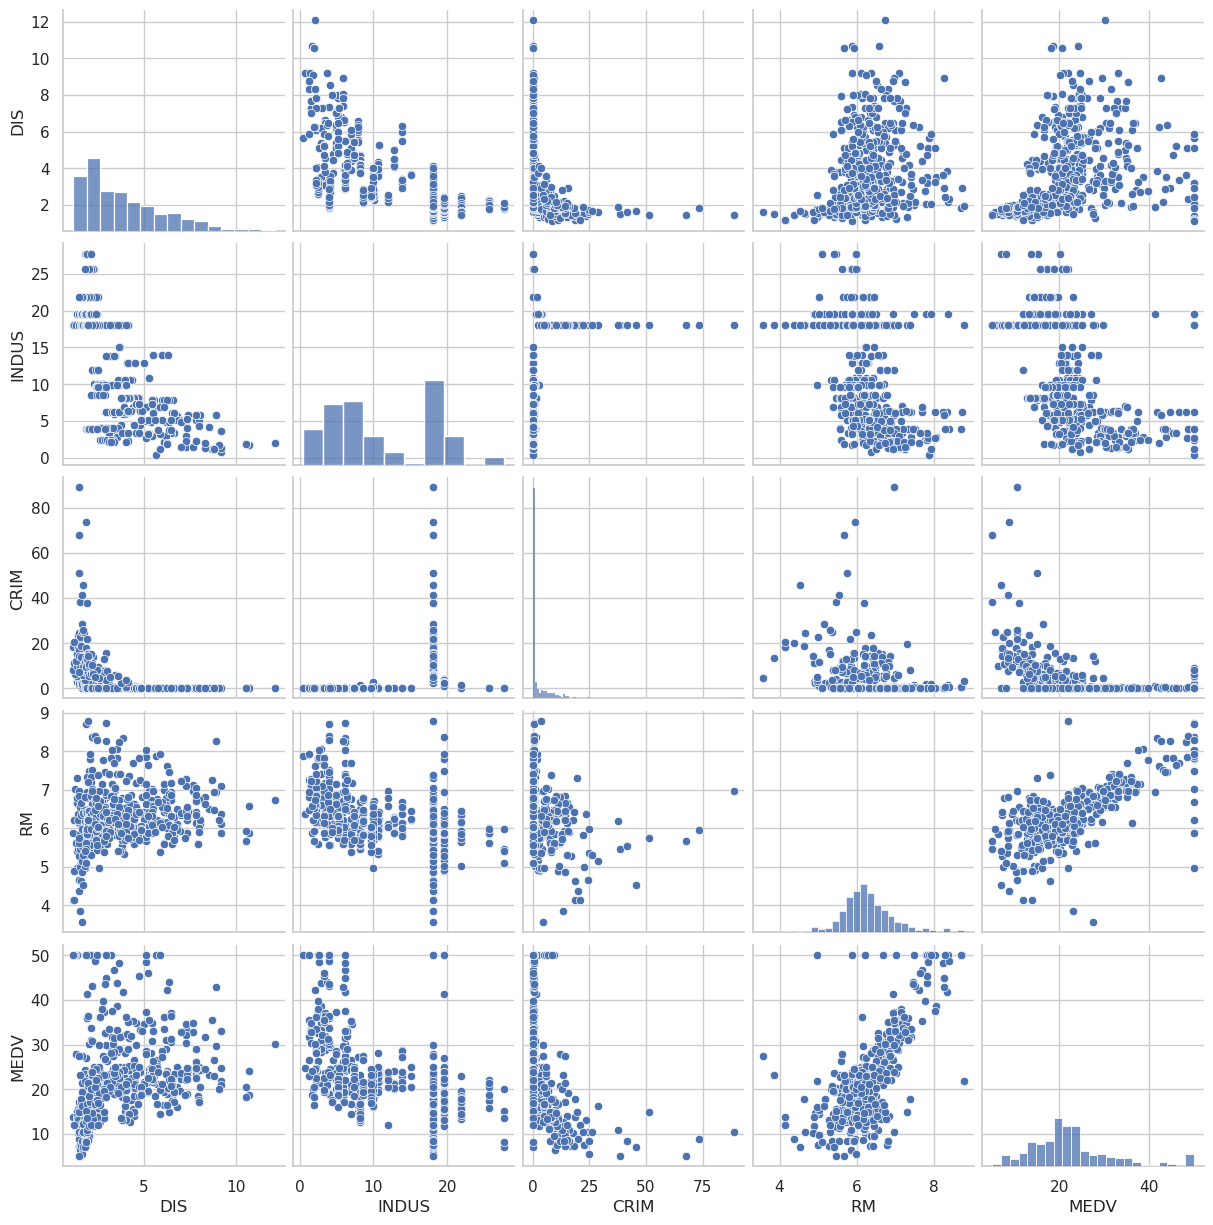

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", context="notebook")
cols = ['DIS', 'INDUS', 'CRIM', 'RM', 'MEDV']
sns.pairplot(df[cols], height=2.5)
plt.show()

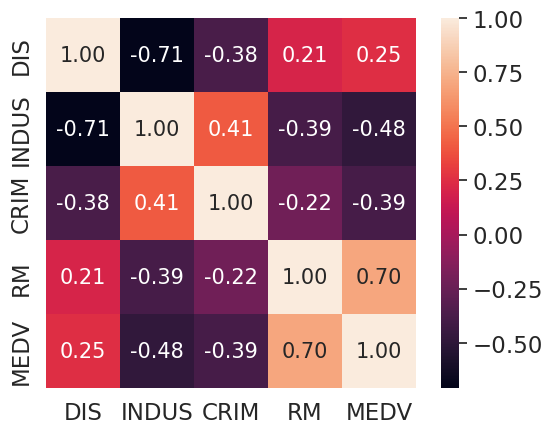

In [3]:
import numpy as np

cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.5)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 15}, yticklabels=cols, xticklabels=cols)
plt.show()

## Creando modelo con sklearn

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X = df['RM'].values
y = df['MEDV'].values

sc_x = StandardScaler()
sc_y = StandardScaler()

X_std = sc_x.fit_transform(X.reshape(-1,1))
y_std = sc_y.fit_transform(y.reshape(-1,1))

print(X_std[:10])
print(y_std[:10])

[[ 0.41367189]
 [ 0.19427445]
 [ 1.28271368]
 [ 1.01630251]
 [ 1.22857665]
 [ 0.20709638]
 [-0.38841095]
 [-0.16046556]
 [-0.9312059 ]
 [-0.39980821]]
[[ 0.15968566]
 [-0.10152429]
 [ 1.32424667]
 [ 1.18275795]
 [ 1.48750288]
 [ 0.6712218 ]
 [ 0.03996443]
 [ 0.49708184]
 [-0.65659542]
 [-0.39538548]]


In [5]:
slr = LinearRegression()
slr.fit(X_std, y_std)

LinearRegression()

## Analisis de resultados

Text(0.5, 0, 'Promedio de habitaciones [RM]')

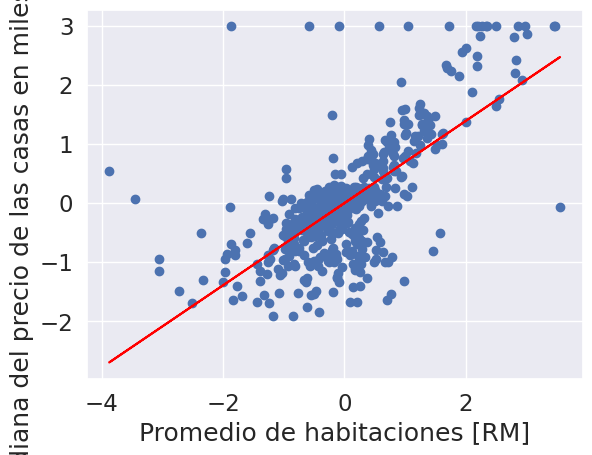

In [9]:
plt.scatter(X_std, y_std)
plt.plot(X_std, slr.predict(X_std), color='red')
plt.ylabel("Mediana del precio de las casas en miles [MEDV]")
plt.xlabel("Promedio de habitaciones [RM]")

In [14]:
# Generando predicciones con el modelo

num_habitaciones = 5
num_habitaciones_std = sc_x.transform(np.array([num_habitaciones]).reshape(-1, 1))
print("El precio de una casa con 5 habitaciones en boston es de ", sc_y.inverse_transform(slr.predict(num_habitaciones_std)))
slr.predict(num_habitaciones_std)

El precio de una casa con 5 habitaciones en boston es de  [[10.83992413]]


array([[-1.2726238]])